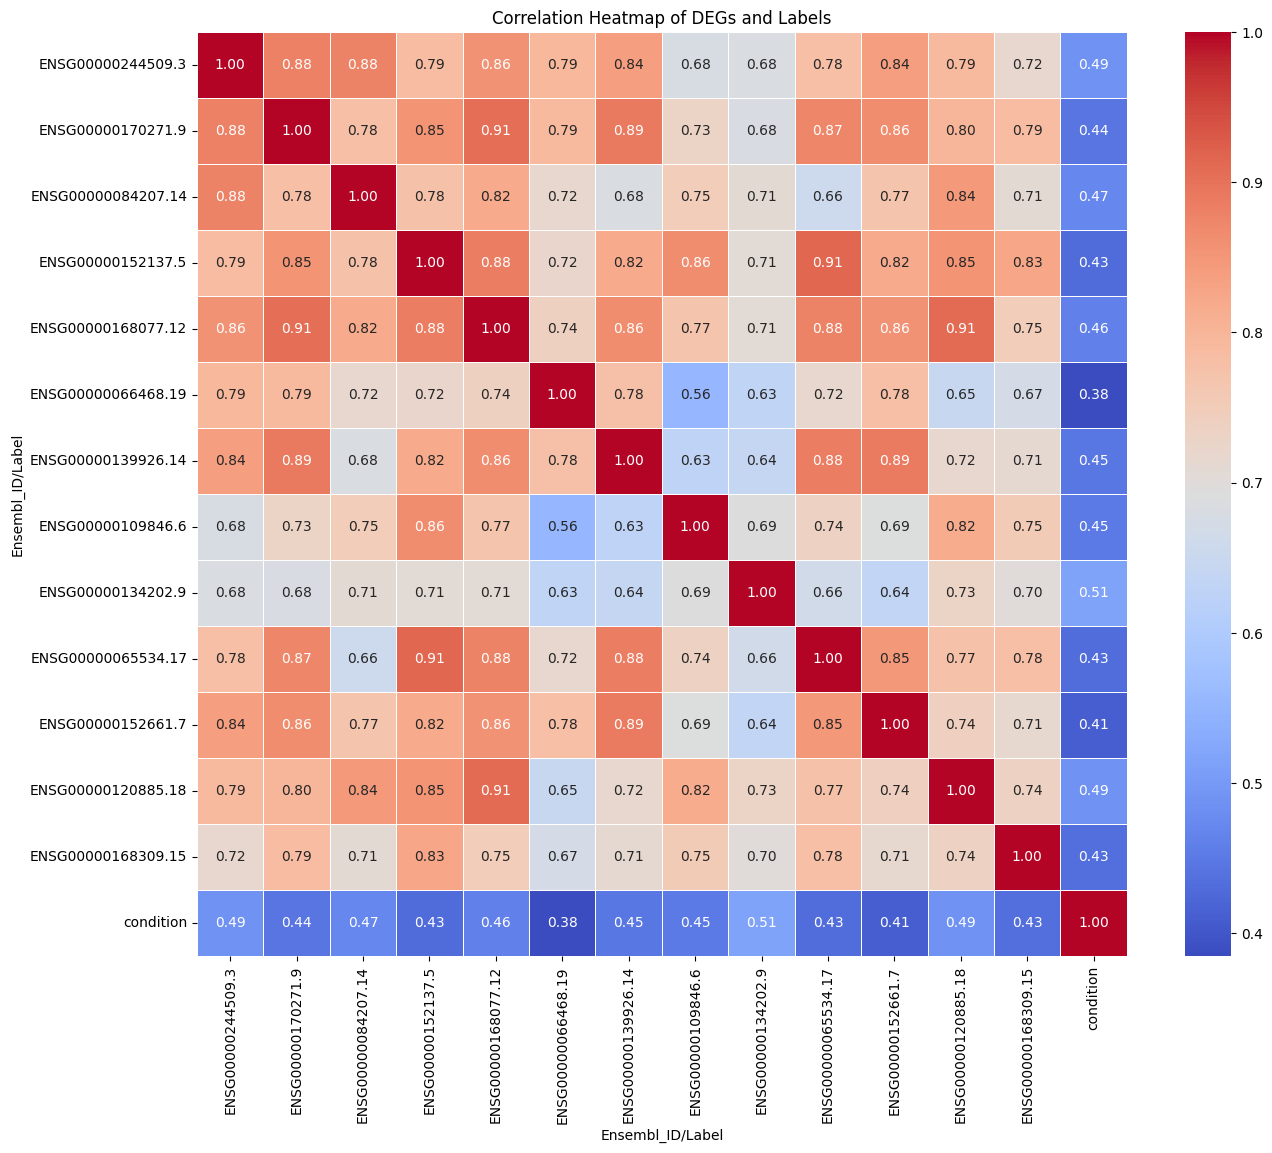

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

degs = pd.read_csv('data13.csv')
degs_numeric = degs.set_index(['Ensembl_ID'])

degs_numeric_transposed = degs_numeric.T

degs_numeric_transposed['condition'] = [0 if '-01' in sample else 1 for sample in degs_numeric_transposed.index]

correlation_matrix = degs_numeric_transposed.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of DEGs and Labels')
plt.xlabel('Ensembl_ID/Label')
plt.ylabel('Ensembl_ID/Label')
plt.show()

#print(correlation_matrix['label'].sort_values(ascending=False))

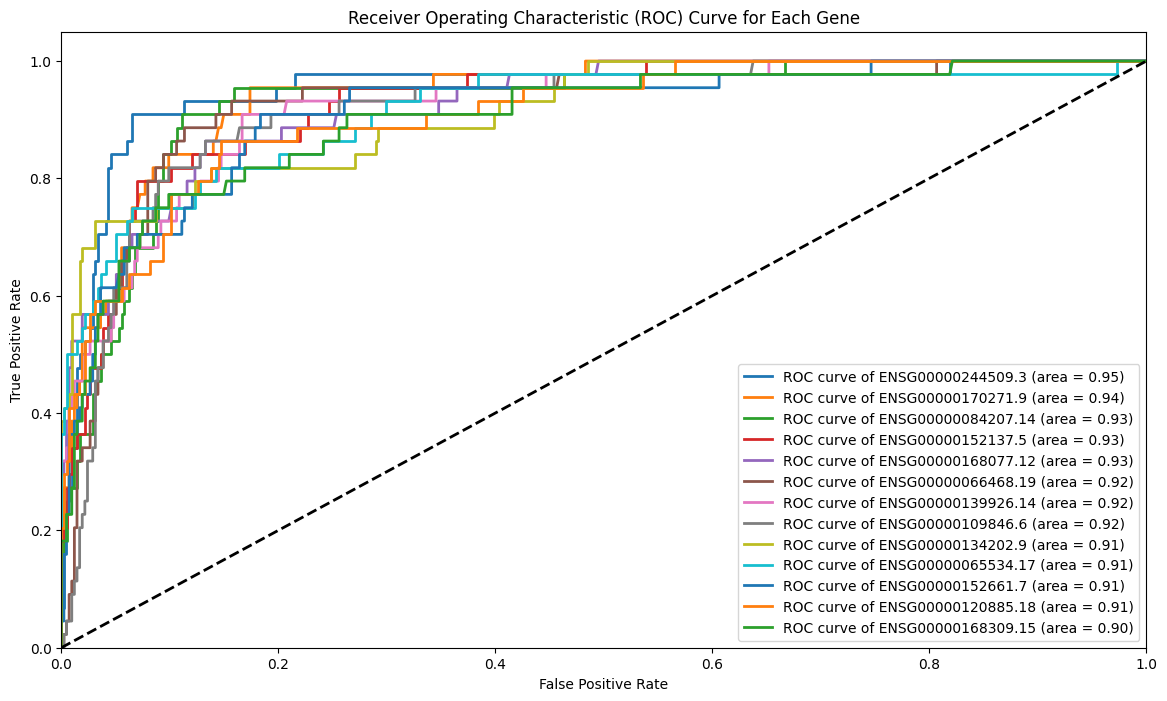

AUC for ENSG00000244509.3: 0.9497
AUC for ENSG00000170271.9: 0.9408
AUC for ENSG00000084207.14: 0.9287
AUC for ENSG00000152137.5: 0.9275
AUC for ENSG00000168077.12: 0.9254
AUC for ENSG00000066468.19: 0.9233
AUC for ENSG00000139926.14: 0.9208
AUC for ENSG00000109846.6: 0.9168
AUC for ENSG00000134202.9: 0.9149
AUC for ENSG00000065534.17: 0.9130
AUC for ENSG00000152661.7: 0.9126
AUC for ENSG00000120885.18: 0.9105
AUC for ENSG00000168309.15: 0.9005


In [2]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import pandas as pd

# Load and prepare the data
degs = pd.read_csv('data13.csv')
degs_numeric = degs.set_index(['Ensembl_ID'])
degs_numeric_transposed = degs_numeric.T
degs_numeric_transposed['condition'] = [0 if '-01' in sample else 1 for sample in degs_numeric_transposed.index]
correlation_matrix = degs_numeric_transposed.corr()

# Prepare X and y
X = degs_numeric_transposed.drop('condition', axis=1).values
y = degs_numeric_transposed['condition'].values

# Binarize the output
y_bin = label_binarize(y, classes=np.unique(y))
n_classes = y_bin.shape[1]

# Compute ROC curve and ROC area for each gene
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(X.shape[1]):  # Iterate through each gene
    fpr[i], tpr[i], _ = roc_curve(y_bin.ravel(), X[:, i].ravel())
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(14, 8))

for i in range(X.shape[1]):
    plt.plot(fpr[i], tpr[i], lw=2,
            label=f'ROC curve of {degs_numeric.index[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Gene')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores for each gene, sorted in descending order
roc_auc_list = [(degs_numeric.index[i], roc_auc[i]) for i in range(X.shape[1])]
roc_auc_list_sorted = sorted(roc_auc_list, key=lambda x: x[1], reverse=True)

for gene, auc_score in roc_auc_list_sorted:
    print(f"AUC for {gene}: {auc_score:.4f}")
